In [8]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
model=ChatOllama(
    model='llama3.2:3b',
    reasoning=False
)

In [ ]:
class state(TypedDict):

    topic : str
    joke : str
    expaination : str

In [4]:
def genrator(state:state):
    prompt=f'genrate the funny joke of following topic {state['topic']}'
    response=model.invoke(prompt).content
    return{'joke':response }


In [5]:
def expaination(state:state):
    prompt=f'genrate the detailed expaination of the follwing joke {state["joke"]}'
    response=model.invoke(prompt).content
    return {'expaination':response}

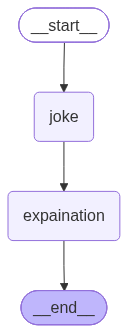

In [ ]:
check=InMemorySaver()
graph=StateGraph(state)

graph.add_node('joke',genrator )
graph.add_node('expaination',expaination)

graph.add_edge(START,'joke')
graph.add_edge('joke','expaination')
graph.add_edge('expaination',END)

workflow=graph.compile(checkpointer=check)
workflow

In [ ]:

config1={'configurable':{'thread_id':"2","checkpoint_id" :'1f18b46e-31b2-66b1-8000-3fcfc825fd12'}}
config={'configurable':{'thread_id':"1"}}
intial_state={'topic':'indian dosa'}

workflow.invoke(intial_state,config=config1)

{'topic': 'indian dosa',
 'joke': 'Here\'s one:\n\nWhy did the Indian Dosa go to therapy?\n\nBecause it was feeling a little "cracked" under the pressure! (get it? like a dosa is cracked wheat, but also feels stressed)',
 'expaination': 'Here\'s a detailed explanation of the joke:\n\nThe joke starts by setting up a scenario where an Indian Dosa, a type of fermented crepe made from rice and lentil batter, goes to therapy. The punchline, "Because it was feeling a little \'cracked\' under the pressure!" is where the humor comes in.\n\nThe wordplay in this joke relies on the double meaning of the term "cracked". In one sense, a Dosa is made from cracked wheat (also known as broken or jaggery rice), which is a common ingredient in its batter. This means that the Dosa itself has cracks or openings in it due to the grinding process.\n\nHowever, the word "cracked" can also have an emotional connotation. When someone is feeling stressed or overwhelmed, they might say they\'re "feeling cracked u

In [23]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'indian dosa', 'joke': 'Why did the Indian Dosa go to therapy?\n\nBecause it was feeling a little "cracked" under the pressure! (get it?)', 'expaination': 'The joke in question is a play on words, combining two concepts: the physical properties of dosas and the common phrase used to describe stress or emotional strain. Let\'s break down the explanation:\n\n**Understanding Dosa**: For those unfamiliar with Indian cuisine, dosa is a traditional fermented crepe made from rice and lentils. It is typically soft, flexible, and slightly crackable when broken.\n\n**The Puns**: The joke relies on two puns:\n\n1. **"Cracked" under the pressure**: This phrase is commonly used to describe someone feeling overwhelmed or stressed. However, it also references the physical property of dosas being "crackable."\n2. **Dosa\'s physical state**: The wordplay hinges on the idea that a dosa, being a soft and flexible food item, might literally be "cracked" under pressure, much 

In [24]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'indian dosa', 'joke': 'Why did the Indian Dosa go to therapy?\n\nBecause it was feeling a little "cracked" under the pressure! (get it?)', 'expaination': 'The joke in question is a play on words, combining two concepts: the physical properties of dosas and the common phrase used to describe stress or emotional strain. Let\'s break down the explanation:\n\n**Understanding Dosa**: For those unfamiliar with Indian cuisine, dosa is a traditional fermented crepe made from rice and lentils. It is typically soft, flexible, and slightly crackable when broken.\n\n**The Puns**: The joke relies on two puns:\n\n1. **"Cracked" under the pressure**: This phrase is commonly used to describe someone feeling overwhelmed or stressed. However, it also references the physical property of dosas being "crackable."\n2. **Dosa\'s physical state**: The wordplay hinges on the idea that a dosa, being a soft and flexible food item, might literally be "cracked" under pressure, much

In [30]:
#time travel in persistace
workflow.get_state({'configurable':{'thread_id':"2","checkpoint_id" :'1f18b46e-31b2-66b1-8000-3fcfc825fd12'}})

StateSnapshot(values={'topic': 'indian dosa'}, next=('joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f18b46e-31b2-66b1-8000-3fcfc825fd12'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-29T12:13:19.937475+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18b46e-31a8-6aea-bfff-b2fa2231d71a'}}, tasks=(PregelTask(id='5676137a-9efc-8e07-403b-be21ddf2c835', name='joke', path=('__pregel_pull', 'joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the Indian Dosa go to therapy?\n\nBecause it was feeling a little "cracked" under the pressure! (get it?)'}),), interrupts=())

In [42]:
workflow.invoke(None,{'configurable':{'thread_id':"2","checkpoint_id" : '1f18b499-4b5a-63fd-8001-d03dc381d'}})

{'topic': 'vadapav',
 'joke': 'Why did the Vadapav vendor break up with his girlfriend?\n\nBecause she was a little "dry" and he needed someone who could add some "chutney" to their relationship!',
 'expaination': 'The joke is a play on words, using the common Indian snack Vada Pav, which consists of a deep-fried doughnut-like structure (vada) served in a bread bun (pav) with various chutneys. Here\'s a detailed explanation:\n\n** setup**: The joke starts by introducing a Vadapav vendor who is in a relationship.\n\n** punchline**: The punchline "she was a little \'dry\'" is a play on words. In the context of Vada Pav, "dry" refers to a type of chutney that lacks moisture and flavor. However, in everyday language, "dry" can also mean uninteresting or lacking excitement.\n\n** connection to the joke**: The vendor breaks up with his girlfriend because she\'s a little "dry", implying that their relationship is lacking excitement or passion. This phrase is often used to describe someone who

In [39]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'vadapav'}, next=('joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18b499-4b5a-63fd-8001-d03dc381d7cd'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-29T12:32:36.900120+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18b46e-31b2-66b1-8000-3fcfc825fd12'}}, tasks=(PregelTask(id='2ab5676f-8aa6-3a7f-5647-cdf1775a4a87', name='joke', path=('__pregel_pull', 'joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 'Here\'s one:\n\nWhy did the samosa go to therapy?\n\nBecause it was feeling a little "cracked" under the pressure! (get it?)', 'expaination': 'Here\'s a detailed explanation of the joke:\n\n**Setup**: The joke starts with a simple question about why a samosa went to therapy. This sets up the expectation that the punchline will be related to the samosa\'

In [38]:
workflow.update_state({'configurable':{'thread_id':"2","checkpoint_id" :'1f18b46e-31b2-66b1-8000-3fcfc825fd12',"checkpoint_ns": ''}},{'topic':'vadapav'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18b499-4b5a-63fd-8001-d03dc381d7cd'}}